In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from nested_pandas import read_parquet
import numpy as np

In [2]:
nf = read_parquet('/global/cfs/cdirs/desc-td/users/mdai/fastdb_dumps/test_out_dir/chunk_0000.parquet')
print(f'{len(nf)} objects')
nf.head()

1000 objects


ra        dec           diaobjectid  \
0  282.909373 -18.680916  [170644231406226204]   
1  252.565374 -18.918723  [170525480875197620]   
2  307.694958 -23.628002  [170591528354316678]   
3  318.419696 -12.661889  [170591526607389090]   
4  260.692795 -16.199554  [170525481535276655]   

                                          lightcurve  \
0  [{diaforcedsourceid: NaN, diasourceid: 1706442...   
1  [{diaforcedsourceid: NaN, diasourceid: 1705254...   
2  [{diaforcedsourceid: NaN, diasourceid: 1705915...   
3  [{diaforcedsourceid: NaN, diasourceid: 1705915...   
4  [{diaforcedsourceid: NaN, diasourceid: 1705254...   

                                 rootid  
0  00000533-33a2-42cf-bfa4-e4951522102f  
1  00001b7e-822c-4030-9b16-cf9cdca02319  
2  00001dd3-dcbc-436f-99d8-5f310e2212ba  
3  00004f91-a3cc-4f46-912b-df70ebb4c131  
4  00005c75-321d-47a7-ad59-9abf192e251b

In [3]:
CONCAT_ALL = True  # set True to load every parquet chunk in out_dir instead of just the one above
WRITE_CONCAT = True  # set True to write the concatenated parquet file to out_dir/concat.parquet

if CONCAT_ALL:
    import glob
    out_dir = '/global/cfs/cdirs/lsst/groups/TD/users/mdai/fastdb_dumps/out_dir/'
    files = sorted(glob.glob(f'{out_dir}/*.parquet'))
    nf = pd.concat([read_parquet(f) for f in files], ignore_index=True)
    print(f'{len(nf)} objects from {len(files)} files')
    if WRITE_CONCAT:
        nf.to_parquet(f'/global/cfs/cdirs/lsst/groups/TD/users/mdai/fastdb_dumps/all_objects_071726.parquet')
nf.head()

501084 objects from 509 files


ra        dec           diaobjectid  \
0  282.909373 -18.680916  [170644231406226204]   
1  252.565374 -18.918723  [170525480875197620]   
2  307.694958 -23.628002  [170591528354316678]   
3  318.419696 -12.661889  [170591526607389090]   
4  260.692795 -16.199554  [170525481535276655]   

                                          lightcurve  \
0  [{diaforcedsourceid: NaN, diasourceid: 1706442...   
1  [{diaforcedsourceid: NaN, diasourceid: 1705254...   
2  [{diaforcedsourceid: NaN, diasourceid: 1705915...   
3  [{diaforcedsourceid: NaN, diasourceid: 1705915...   
4  [{diaforcedsourceid: NaN, diasourceid: 1705254...   

                                 rootid  
0  00000533-33a2-42cf-bfa4-e4951522102f  
1  00001b7e-822c-4030-9b16-cf9cdca02319  
2  00001dd3-dcbc-436f-99d8-5f310e2212ba  
3  00004f91-a3cc-4f46-912b-df70ebb4c131  
4  00005c75-321d-47a7-ad59-9abf192e251b

In [4]:
nf = read_parquet('/global/cfs/cdirs/lsst/groups/TD/users/mdai/fastdb_dumps/all_objects_071726.parquet')

In [5]:
# compute some quanties
from nested_pandas.utils import count_nested

nf = count_nested(nf.query("lightcurve.isdet == True"),by="band",nested="lightcurve")
nf = count_nested(nf.query("lightcurve.isdet == True"),by="isdet",nested="lightcurve")
nf = nf.rename(columns = {"n_lightcurve_True": "ndet"})
nf["lightcurve.snr"] = nf["lightcurve.flux"]/nf["lightcurve.fluxerr"]
nf = nf.map_rows(lambda row: np.sum(np.unique_counts(row).counts>0), columns="lightcurve.band", row_container="args", output_names="nbands", append_columns=True)

# # filter objects

nf = nf.query("ndet > 10 and "
              "nbands > 2")


/global/common/software/lsst/install/td_env/2026-05-28-05-05/py/envs/td_env/lib/python3.12/site-packages/nested_pandas/nestedframe/core.py:1476: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/global/common/software/lsst/install/td_env/2026-05-28-05-05/py/envs/td_env/lib/python3.12/site-packages/nested_pandas/nestedframe/core.py:1476: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)
/global/common/software/lsst/install/td_env/2026-05-28-05-05/py/envs/td_env/lib/python3.12/site-packages/nested_pandas/nestedframe/core.py:1476: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  answer = super().eval(expr, **kwargs)


In [6]:
nf

ra        dec           diaobjectid  \
16       61.571938 -48.320214  [170028485934841908]   
62      186.052702   7.463899  [170028528616603726]   
...            ...        ...                   ...   
501041   60.411086 -48.261226  [314007345763975171]   
501068   58.267642 -50.252586  [170028487412285504]   

                                               lightcurve  \
16      [{diaforcedsourceid: NaN, diasourceid: 1700284...   
62      [{diaforcedsourceid: NaN, diasourceid: 1700285...   
...                                                   ...   
501041  [{diaforcedsourceid: NaN, diasourceid: 3140073...   
501068  [{diaforcedsourceid: NaN, diasourceid: 1700284...   

                                      rootid  n_lightcurve_g  n_lightcurve_i  \
16      0001f1c8-d893-4bd4-a753-80cdccc452ec               0              20   
62      00090d66-5874-476c-903c-de3912670005              46              41   
...                                      ...             ...             ...   
501041  fff94549-5e0d-43ef-9ff4-f374c8e5b6c3               2               5   
501068  fffe3bbe-e779-484f-bb48-61582386a1aa               5               6   

        n_lightcurve_r  n_lightcurve_u  n_lightcurve_y  n_lightcurve_z  ndet  \
16                  14               0               0               6    40   
62                  16               0               0               0   103   
...                ...             ...             ...             ...   ...   
501041               4               0               0               0    11   
501068              29               0               0               3    43   

        nbands  
16           3  
62           3  
...        ...  
501041       3  
501068       4  

[34879 rows x 13 columns]

In [7]:
def lc_quality_cuts(flux,mjd,filter,snr, n_phases=5, n_before_peak=1, n_after_peak=2, n_bands=3):
    det = snr > 5
    flux = flux[det]
    mjd = mjd[det]
    filter = filter[det]
    if len(flux) == 0:
        return False
    peak_idx = np.argmax(flux)
    phases = np.floor((mjd - mjd[peak_idx]))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -40) & (unique_phases<=100)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    flux_new = flux[unique_idx][good_idx]
    peak_idx_new = np.argmax(flux_new)
    pass_cut &= (peak_idx_new >= n_before_peak - 1) & (len(flux_new) - peak_idx_new >= n_after_peak - 1)
    good_phases = (phases >= -40) & (phases<=100)
    pass_cut &= len(np.unique(filter[good_phases])) >= n_bands
    return pass_cut

In [8]:
nf = nf.map_rows(lc_quality_cuts,
                 columns=["lightcurve.flux",
                          "lightcurve.mjd",
                          "lightcurve.band",
                          "lightcurve.snr"],
                 row_container="args",
                 output_names="pass_quality_cuts",
                 append_columns=True)

In [9]:
nf = nf.query("pass_quality_cuts == True")

In [10]:
nf

ra        dec                              diaobjectid  \
151      62.484587 -47.013235                     [314002971880849457]   
152     148.790573   2.496672  [313853533656973342 313963405777567766]   
...            ...        ...                                      ...   
500948  150.717681   3.707175                     [170028512536690737]   
501068   58.267642 -50.252586                     [170028487412285504]   

                                               lightcurve  \
151     [{diaforcedsourceid: NaN, diasourceid: 3140029...   
152     [{diaforcedsourceid: NaN, diasourceid: 3138535...   
...                                                   ...   
500948  [{diaforcedsourceid: NaN, diasourceid: 1700285...   
501068  [{diaforcedsourceid: NaN, diasourceid: 1700284...   

                                      rootid  n_lightcurve_g  n_lightcurve_i  \
151     0013fab7-58cc-4ad3-a142-296f38b10a63              72              70   
152     00143d0c-fe4a-4ab3-ab88-6ad47acd757a             235              81   
...                                      ...             ...             ...   
500948  ffedf84a-7f11-410d-af1d-01225c0d95e4              96              39   
501068  fffe3bbe-e779-484f-bb48-61582386a1aa               5               6   

        n_lightcurve_r  n_lightcurve_u  n_lightcurve_y  n_lightcurve_z  ndet  \
151                 83               0               0               1   226   
152                146              28               0               3   493   
...                ...             ...             ...             ...   ...   
500948              67               0               0               0   202   
501068              29               0               0               3    43   

        nbands  pass_quality_cuts  
151          4               True  
152          5               True  
...        ...                ...  
500948       3               True  
501068       4               True  

[5689 rows x 14 columns]

In [11]:
colors = {"u": "blue",
          "g": "green",
          "r": "red",
          "i": "purple",
          "z": "orange",
          "y": "brown"}
def plot_lc(lc,saltpars=None):
    maxflux = 0.
    for f in lc["band"].unique():
        lc_f = lc.loc[lc["band"]==f]
        is_det = np.absolute(lc_f["snr"]) > 5
        lc_det = lc_f.loc[is_det]
        lc_nondet = lc_f.loc[~is_det]
        plt.errorbar(lc_det["mjd"],lc_det["flux"],yerr=lc_det["fluxerr"],fmt='o',label=f, c=colors[f])
        plt.errorbar(lc_nondet["mjd"],lc_nondet["flux"],yerr=lc_nondet["fluxerr"],fmt='>',alpha=0.3, c=colors[f])

        if saltpars is not None:
            model = sncosmo.Model("salt3",effects=[sncosmo.F99Dust()], effect_names=["mw"], effect_frames=["obs"])
            model.update(saltpars)
            time = np.linspace(-20,50,100)*(1.+saltpars["z"]) + saltpars["t0"]
            try:
                flux = model.bandflux("lsst"+f,time,zp=31.4, zpsys='ab')
                maxflux = np.max(np.append(flux,maxflux))
                plt.plot(time,flux,c=colors[f],alpha=0.1,ls="--")
            except:
                continue
        plt.legend()
    is_det = np.absolute(lc["snr"]) > 5
    if saltpars:
        ylim = (-0.2*maxflux, maxflux*1.5)
    else:
        ylim = (-0.2*lc.loc[is_det]["flux"].max(),lc.loc[is_det]["flux"].max()*1.5)
    plt.ylim(ylim)

seed=[4930]
1494


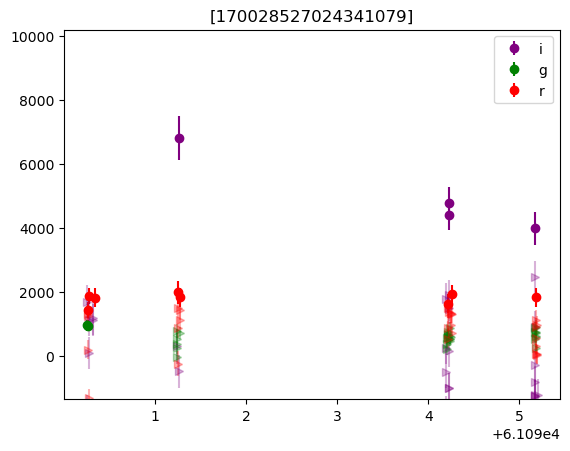

4742


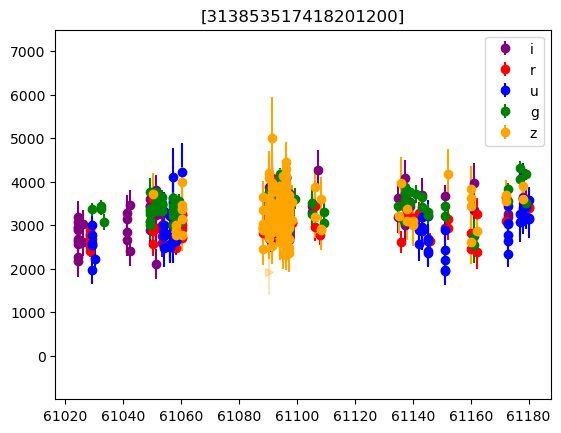

812


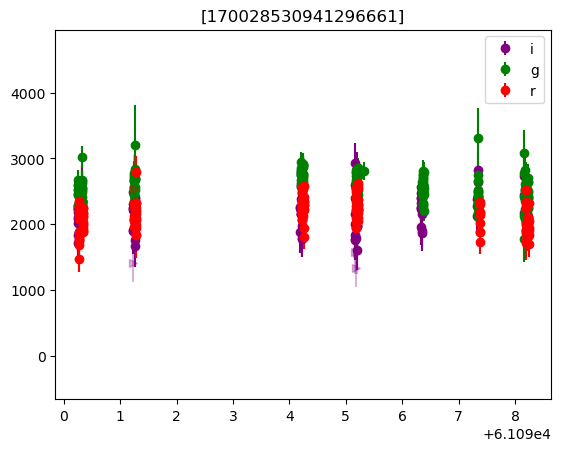

5165


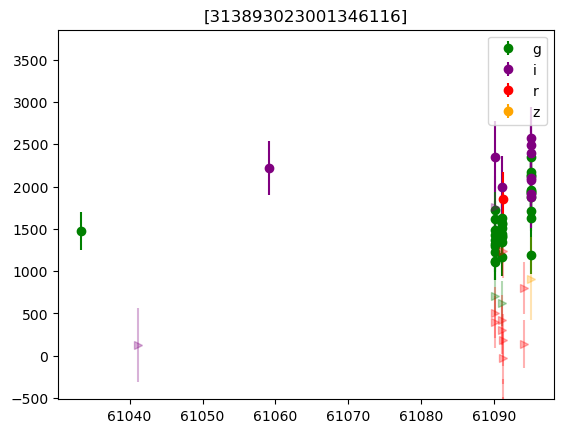

907


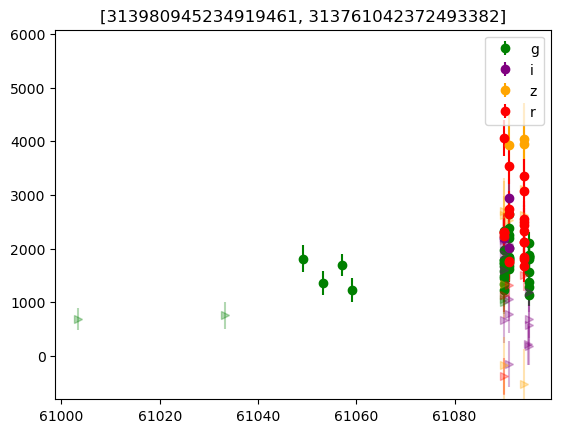

1182


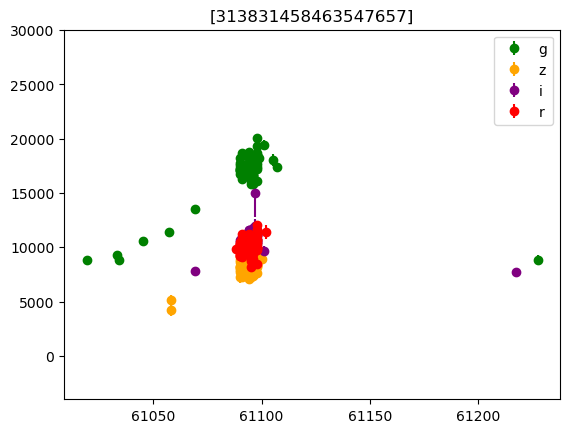

1060


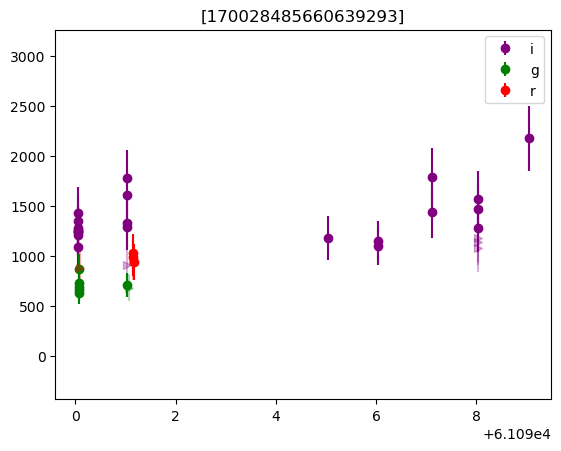

4667


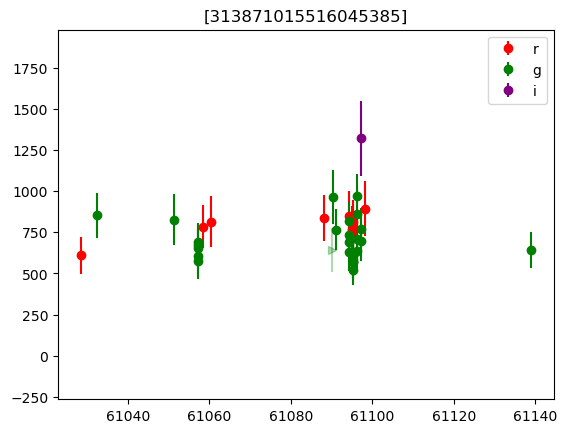

3021


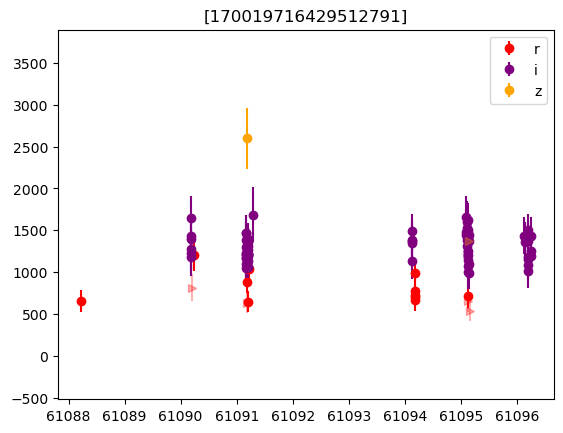

5408


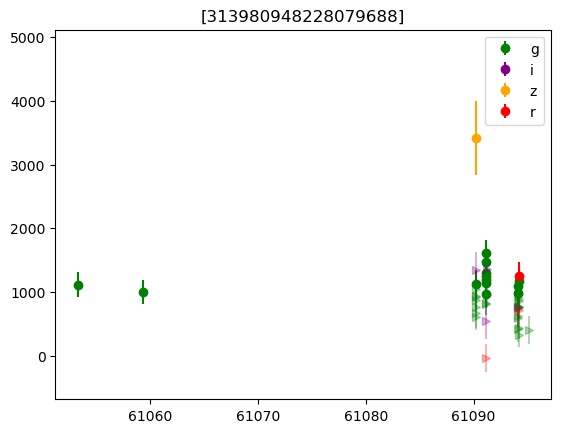

In [12]:
seed = np.random.randint(0,10000,1)
print(f"seed={seed}")
rng = np.random.default_rng(seed)
for i in rng.choice(len(nf),size=np.min([10,len(nf)]),replace=False):
    print(i)
    lc = nf.iloc[i]["lightcurve"]
    plot_lc(lc)
    plt.title(nf.iloc[i]["diaobjectid"])
    plt.show()